In [1]:
library(tidyverse)
library(viridis)

── Attaching packages ─────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.3     ✔ forcats 1.0.0
── Conflicts ────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Loading required package: viridisLite



In [2]:
figs_df <- "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs"
cpdb_dir <- "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/cpdb"

In [5]:
dirs <- list.files(cpdb_dir,pattern=".statistical",full.names=T)
dirs <- dirs[!endsWith(dirs,".metadata.tsv")]
for (dir in dirs) {
    files <- list.files(dir,pattern=".csv",full.names=T)
    for (path in files) {
        label <- sub(".csv","",basename(path))
        # fig_path <- file.path(figs_df,paste0(label,".png"))
        fig_path <- file.path(figs_df,paste0(label,".filtered_nonsignificant.png"))
        if (file.exists(fig_path)) { next }
        print(fig_path)
        df <- read.csv(path)
        # p <- ggplot(df,aes(x=celltype_group,y=interaction_group)) +
        #     geom_point(aes(size=scaled_means,color=scaled_means,shape=significant),alpha=0.95) +
        #     scale_color_viridis(option="viridis") +
        #     scale_shape_manual(values=c(19,1)) +
        #     coord_cartesian(clip="off") +
        #     theme_light() + theme(
        #         axis.text.x = element_text(angle=90,hjust=1,vjust=0.5),
        #         strip.text.y = element_text(angle=0,color="white"),
        #         strip.background = element_rect(fill="#404040",color="gray75"),
        #     ) +
        #     facet_grid(directionality~.,space="free",scale="free")
        # ggsave(fig_path,p,width=16,height=48,dpi="retina")
        p <- df %>%
            filter(significant == "yes") %>%
            ggplot(aes(x=interaction_group,y=celltype_group,fill=scaled_means)) +
            geom_tile() +
            scale_fill_viridis(option="viridis") +
            facet_grid(~directionality,space="free",scales="free") +
            theme_minimal() + theme(
                axis.text.x = element_text(angle=90,hjust=1,vjust=0.5),
                legend.position = "top",
                strip.background = element_rect(fill="#404040"),
                strip.text.x = element_text(color="white",angle=90)
            )
        ggsave(fig_path,p,width=40,height=10,dpi="retina")
    }
}

[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_10.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_11.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_14.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_15.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_16.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_17.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__cardio_6.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO__endo_4.filtered_nonsignificant.png"
[1] "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/figs/BHO_

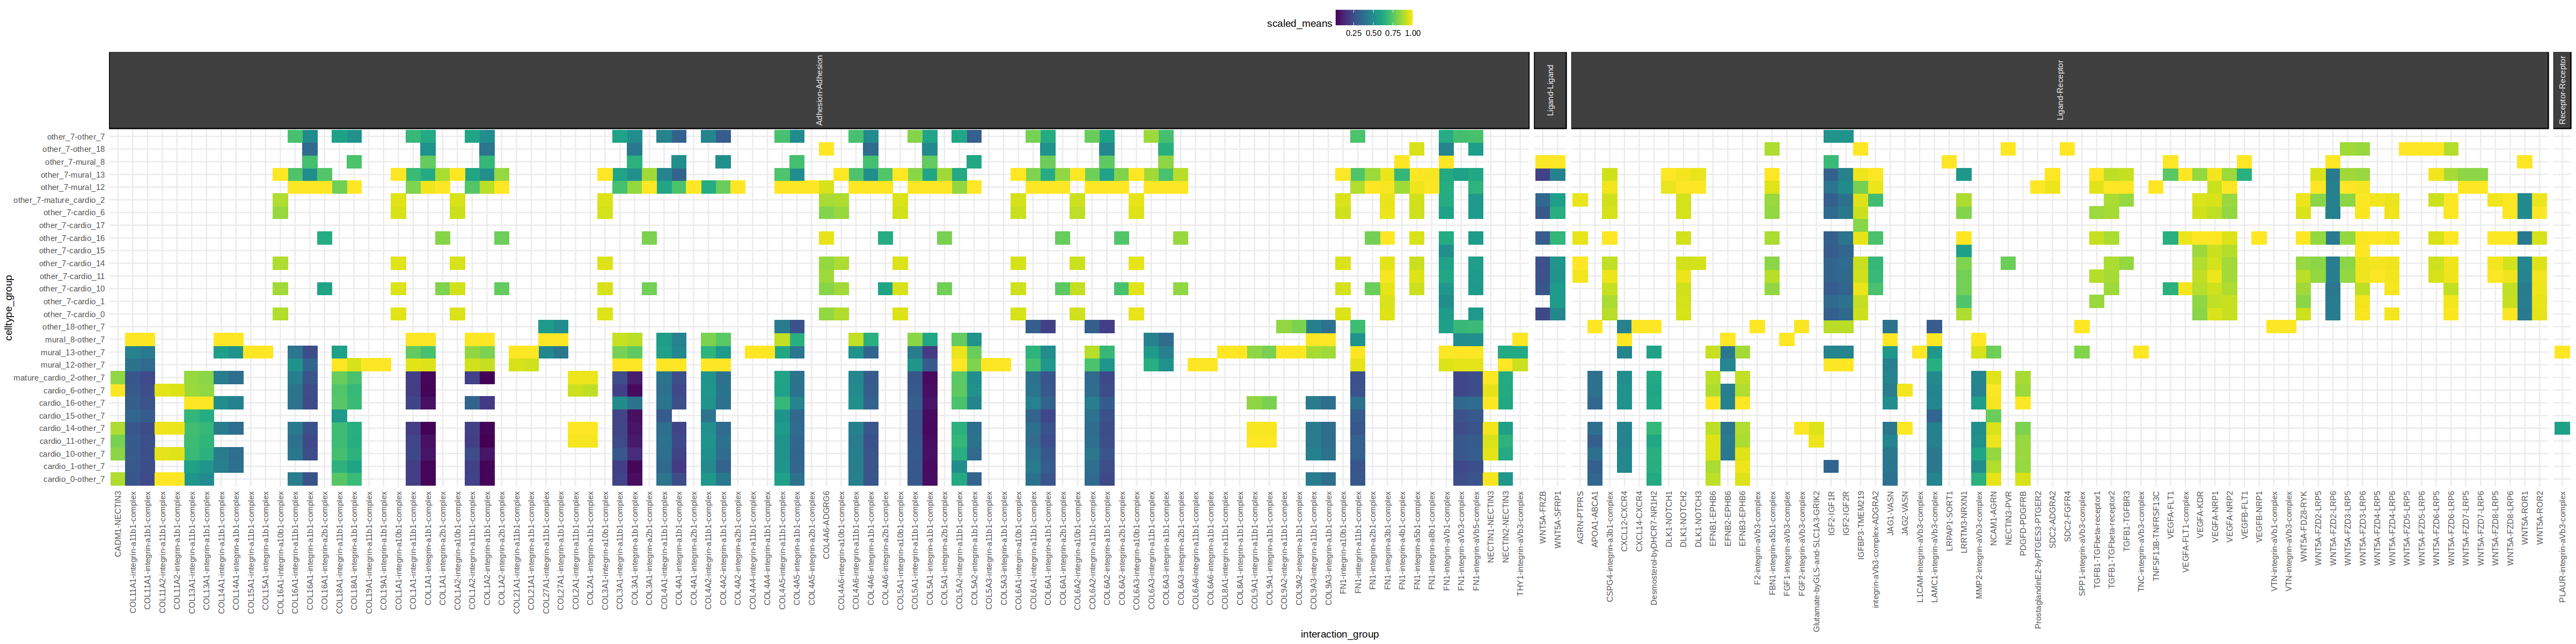

In [6]:
options(repr.plot.width=40,repr.plot.height=10)
p

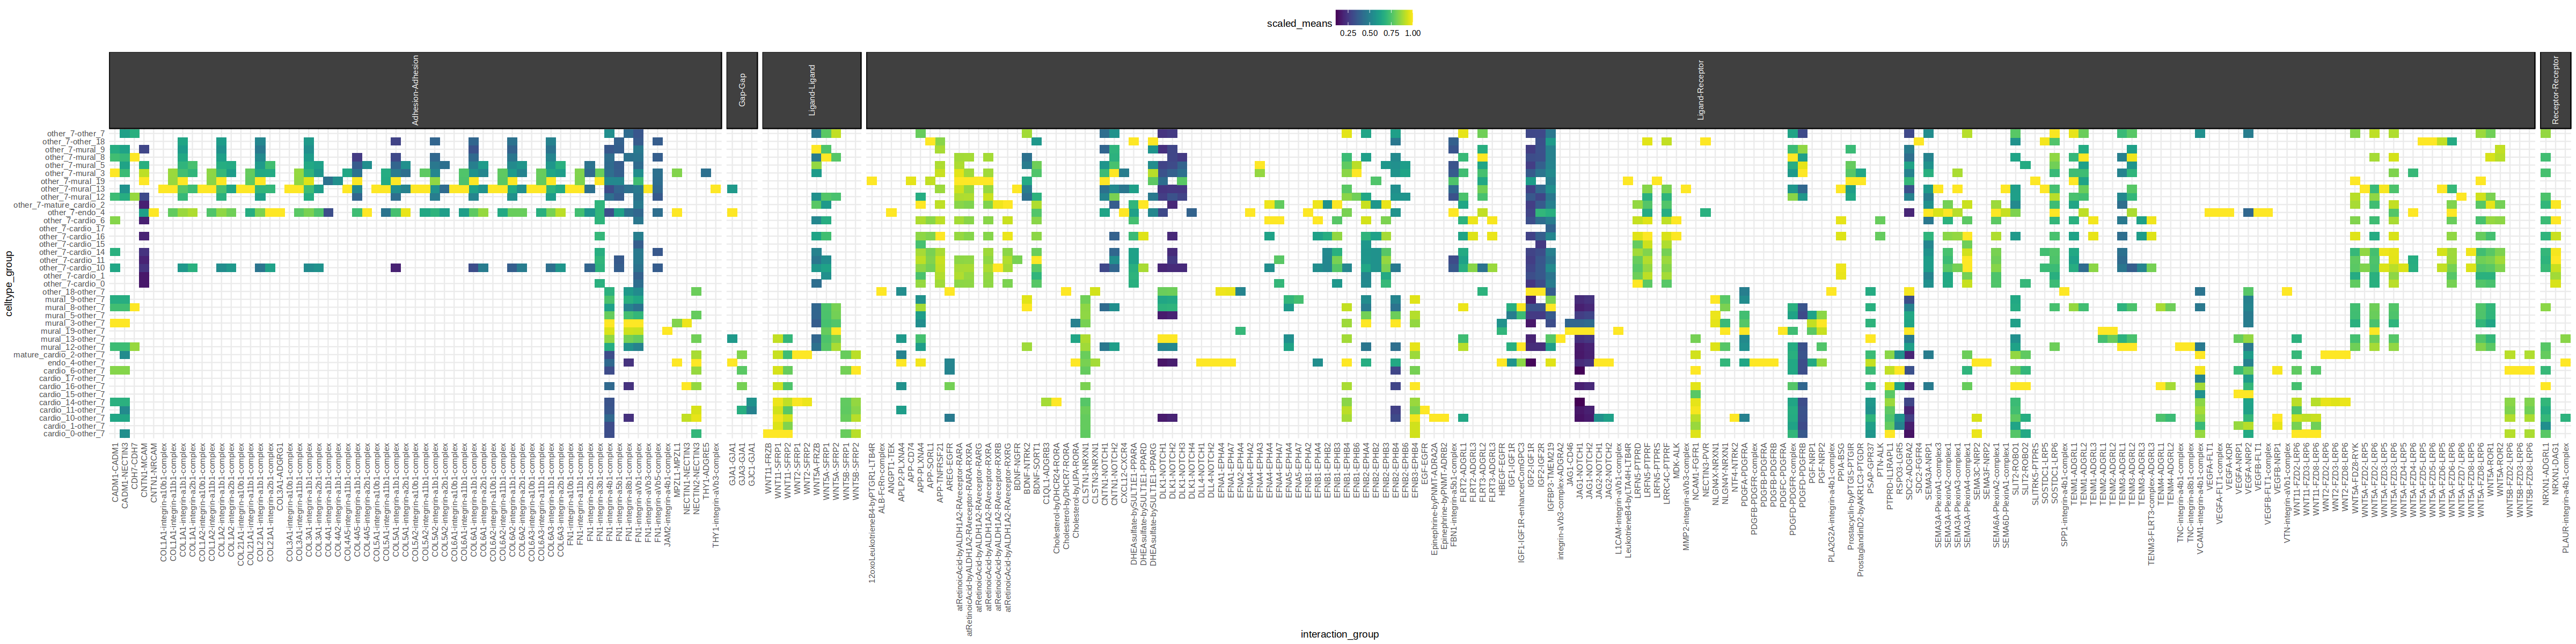

In [102]:
options(repr.plot.width=40,repr.plot.height=10)
df %>%
    filter(significant == "yes") %>%
    ggplot(aes(x=interaction_group,y=celltype_group,fill=scaled_means)) +
    geom_tile() +
    scale_fill_viridis(option="viridis") +
    facet_grid(~directionality,space="free",scales="free") +
    theme_minimal() + theme(
        axis.text.x = element_text(angle=90,hjust=1,vjust=0.5),
        legend.position = "top",
        strip.background = element_rect(fill="#404040"),
        strip.text.x = element_text(color="white",angle=90)
    )

In [3]:
df_path <- "/home/brett/work/Cell2CellCommunication/jun_coculture_dataset/cpdb/CM3B.statistical/plot_df.csv"

In [4]:
df <- read.csv(df_path)
dim(df)
head(df)

[1] 12948    13

,X,interaction_group,celltype_group,scaled_means,pvals,x_means,y_means,x_stroke,neglog10p,significant,is_integrin,directionality,classification
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,CPI-SC0DF13E412---ALB-FcRn-complex---cardio_0-mural_5,ALB-FcRn-complex,cardio_0-mural_5,0.1753744,1.000,0.1753744,NA,0,0,no,False,Ligand-Receptor,
2,CPI-SS0D8632EB4---EDN1-EDNRA---cardio_0-mural_5,EDN1-EDNRA,cardio_0-mural_5,0.7759398,1.000,0.7759398,NA,0,0,no,False,Ligand-Receptor,Signaling by Endothelin
3,CPI-SS0730D1EF3---CNTN1-MCAM---cardio_0-mural_5,CNTN1-MCAM,cardio_0-mural_5,0.7276074,1.000,0.7276074,NA,0,0,no,False,Adhesion-Adhesion,
4,CPI-SS0C21302BC---NCAM1-AGRN---cardio_0-mural_5,NCAM1-AGRN,cardio_0-mural_5,0.7301415,0.001,NA,0.7301415,1,3,yes,False,Ligand-Receptor,Signaling by Leucine-Rich Repeat Transmembrane Neuronal Protein
5,CPI-SC04266947A---BMP2-BMR1A-AVR2B---cardio_0-mural_5,BMP2-BMR1A-AVR2B,cardio_0-mural_5,0.8629630,0.001,NA,0.8629630,1,3,yes,False,Ligand-Receptor,Signaling by BMP
6,CPI-SC070B9F112---BMP2-BMPR1A-BMPR2---cardio_0-mural_5,BMP2-BMPR1A-BMPR2,cardio_0-mural_5,0.8684211,0.001,NA,0.8684211,1,3,yes,False,Ligand-Receptor,Signaling by BMP


In [26]:
length(unique(df$directionality))

[1] 5

Warning message:
“Removed 2381 rows containing missing values or values outside the scale range
(`geom_point()`).”


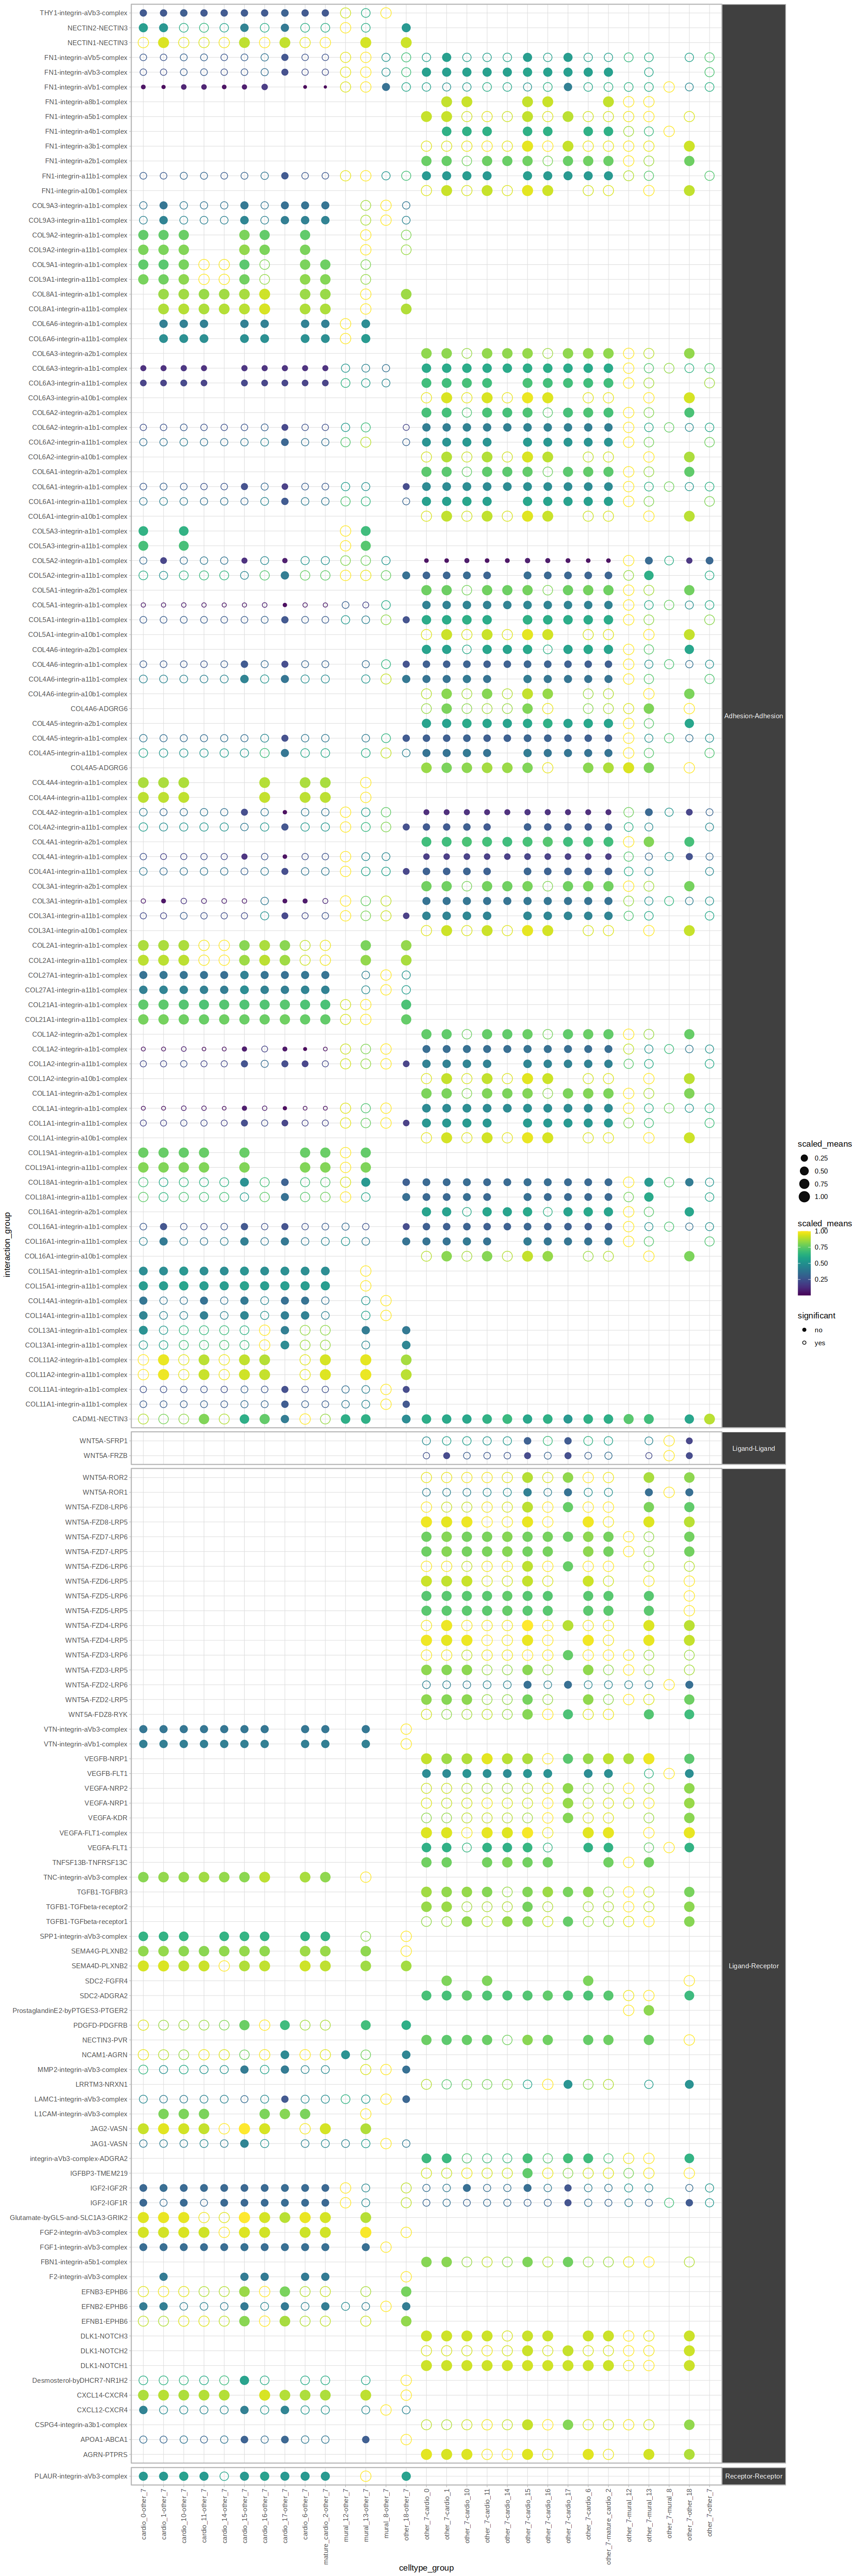

In [70]:
options(repr.plot.width=16,repr.plot.height=48)
ggplot(df,aes(x=celltype_group,y=interaction_group)) +
    geom_point(aes(size=scaled_means,color=scaled_means,shape=significant),alpha=0.95) +
    scale_color_viridis(option="viridis") +
    scale_shape_manual(values=c(19,1)) +
    coord_cartesian(clip="off") +
    theme_light() + theme(
        axis.text.x = element_text(angle=90,hjust=1,vjust=0.5),
        strip.text.y = element_text(angle=0,color="white"),
        strip.background = element_rect(fill="#404040",color="gray75"),
    ) +
    facet_grid(directionality~.,space="free",scale="free")